# STAT 7220 - Midterm Exam
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: March 6, 2026**

**PART 1 INSTRUCTIONS:** Suppose you are a video game controller manufacturer interested in estimating the perceived comfort level of controller grips. To achieve this, you decide to conduct an experiment to assess different material types used for the controller grips (plastic, rubber, silicone, and metal). 10 prototypes of each grip type are manufactured and given to professional gamers (who all play the same game -- Apex Legends) to test. The gamers use the controllers regularly for one month and then rate the comfort level on a scale from 1 - 10 with greater scores indicating a greater level of perceived comfort (one decimal allowed). The data from this experiment are stored in the Video Game Controllers.xlsx file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

The objective of this experiment is to determine whether the type of grip material used in a video game controller affects the perceived comfort level reported by professional gamers after regular use over one month.

**Question 2.** Specify the outcome variable

The outcome variable is the comfort rating given by professional gamers after using each controller prototype for one month. The rating is measured on a scale from 1 to 10, where higher values indicate greater perceived comfort.

**Question 3.** Specify the independent variable. What are some possible lurking variables?

**Independent Variable**

The independent variable is **grip material type**, with four levels:

- Plastic  
- Rubber  
- Silicone  
- Metal  

**Possible Lurking Variables**

- Hand size of the gamer  
- Grip style or playing posture  
- Hours of gameplay during the month  
- Sweating or skin sensitivity  
- Small manufacturing differences other than material

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

A completely randomized design may be appropriate because the main factor of interest is grip material, and the controllers can be randomly assigned to gamers so that each prototype has an equal chance of being tested under similar conditions. Randomization helps reduce bias and balances other uncontrolled factors across treatment groups, making it more reasonable to attribute differences in comfort ratings to the material type rather than other sources of variation.

**Question 5.** State the null and alternative hypotheses for this experiment.

Let

- $\mu_{Plastic}$ = mean comfort score for plastic grips  
- $\mu_{Rubber}$ = mean comfort score for rubber grips  
- $\mu_{Silicone}$ = mean comfort score for silicone grips  
- $\mu_{Metal}$ = mean comfort score for metal grips  

**Null hypothesis**

$$
H_0: \mu_{Plastic} = \mu_{Rubber} = \mu_{Silicone} = \mu_{Metal}
$$

**Alternative hypothesis**
$$
H_A: \text{At least one mean comfort score differs among the material types}
$$

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_excel("Video Game Controllers.xlsx")

# Check structure
print(data.info())
print(data.head())

# Summary statistics by material
summary = data.groupby("Material")["Comfort"].agg(
    n="count",
    mean="mean",
    sd="std",
    min="min",
    median="median",
    max="max"
)

print(summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Material  40 non-null     object 
 1   Comfort   40 non-null     float64
dtypes: float64(1), object(1)
memory usage: 772.0+ bytes
None
  Material  Comfort
0  Plastic      5.7
1  Plastic      6.3
2  Plastic      6.8
3  Plastic      6.0
4  Plastic      5.8
           n  mean        sd  min  median  max
Material                                      
Metal     10  5.39  0.877433  4.0    5.25  6.5
Plastic   10  5.93  0.620125  4.6    5.95  6.8
Rubber    10  6.23  0.702456  4.9    6.40  7.5
Silicone  10  7.63  0.700872  6.6    7.90  8.4


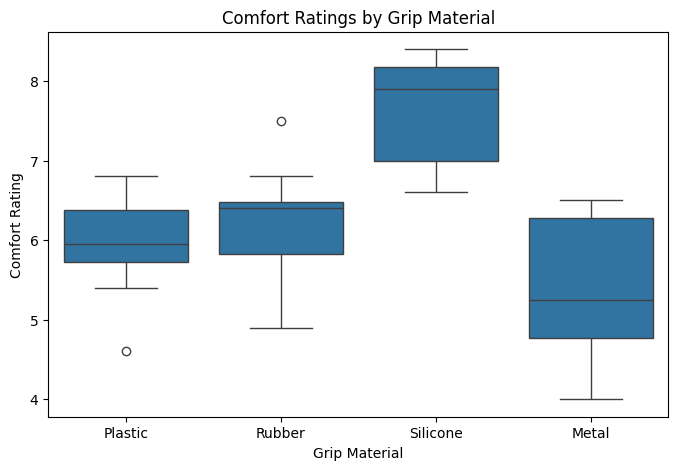

In [ ]:
# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x="Material", y="Comfort", data=data)
plt.title("Comfort Ratings by Grip Material")
plt.xlabel("Grip Material")
plt.ylabel("Comfort Rating")
plt.show()

From the summary statistics, the average comfort ratings differed across the materials. Silicone had the highest mean comfort rating (7.63), followed by rubber (6.23), plastic (5.93), and metal (5.39). The medians showed a similar pattern, with silicone having the highest median (7.90) and metal the lowest (5.25). These values suggest that silicone grips were generally rated as the most comfortable, while metal grips were rated as the least comfortable.

The boxplot also shows noticeable differences among the groups. Silicone ratings are clearly higher than the other materials, with most values falling between about 7.0 and 8.2. Metal has the lowest center overall and also shows a fairly wide spread, indicating greater variability in comfort ratings. Silicone also shows some variability, but its ratings are still consistently higher than the other groups. Plastic and rubber appear closer to each other, although rubber tends to have slightly higher ratings overall.

There appears to be one lower outlier for plastic and one higher outlier for rubber. The boxplots also suggest minor differences in distribution shape across the groups, although with only 10 observations per group these patterns should be interpreted cautiously.

Overall, both the summary statistics and the boxplot suggest that comfort ratings may differ across the four grip materials. These exploratory results appear more consistent with the alternative hypothesis than the null hypothesis, although a formal ANOVA test is required to confirm this.

**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using *both* a testing and visual method. Do the results of the normality test(s) support the assumption of normality?


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit ANOVA model
model = ols('Comfort ~ C(Material)', data=data).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

             sum_sq    df          F        PR(>F)
C(Material)  27.387   3.0  17.070642  4.616153e-07
Residual     19.252  36.0        NaN           NaN


In [ ]:
from scipy.stats import shapiro

# Extract residuals
residuals = model.resid

# Shapiro-Wilk test
shapiro_test = shapiro(residuals)

print("Shapiro-Wilk Test Statistic:", shapiro_test.statistic)
print("p-value:", shapiro_test.pvalue)

Shapiro-Wilk Test Statistic: 0.9710174538151857
p-value: 0.3874084700249114


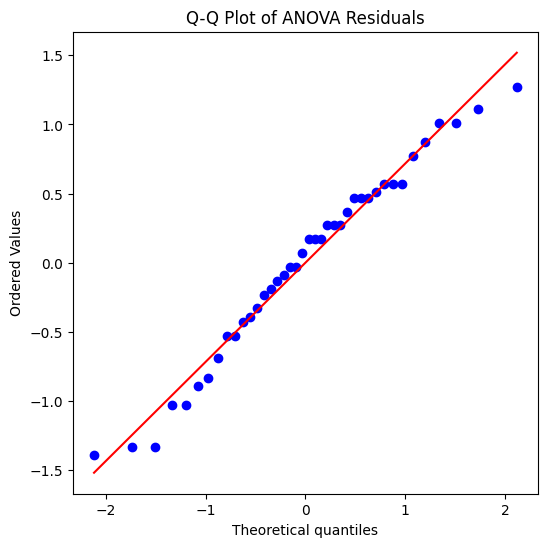

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of ANOVA Residuals")
plt.show()

A one-way ANOVA model was built to evaluate whether the mean comfort ratings differ across the four grip materials.

To check the normality assumption, both a statistical test and a visual method were used. First, the Shapiro–Wilk test was applied to the residuals from the ANOVA model. The test produced a p-value of 0.387. Since this value is greater than 0.05, we fail to reject the null hypothesis of the Shapiro–Wilk test, indicating that the residuals do not show evidence of departing from normality.

A Q–Q plot of the residuals was also examined. Most of the points fall close to the reference line, which suggests the residuals follow an approximately normal distribution. A few points near the lower and upper ends deviate slightly from the line, but these differences are small and not unusual with a sample of this size.

Based on both the Shapiro–Wilk test and the Q–Q plot, the normality assumption for the ANOVA model appears to be reasonably satisfied.

**Question 8.** Test the assumption of homogeneity of variance using *both* a testing and visual method. Do the results of the test(s) support the assumption of homogeneity of variance?


In [ ]:
from scipy.stats import levene

plastic = data[data["Material"] == "Plastic"]["Comfort"]
rubber = data[data["Material"] == "Rubber"]["Comfort"]
silicone = data[data["Material"] == "Silicone"]["Comfort"]
metal = data[data["Material"] == "Metal"]["Comfort"]

levene_test = levene(plastic, rubber, silicone, metal)

print("Levene Test Statistic:", levene_test.statistic)
print("p-value:", levene_test.pvalue)

Levene Test Statistic: 0.5784720527215035
p-value: 0.6329252655165909


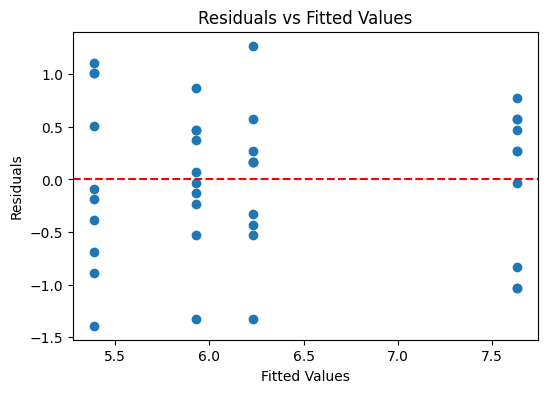

In [ ]:
import matplotlib.pyplot as plt

fitted_vals = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(6,4))
plt.scatter(fitted_vals, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

The homogeneity of variance assumption was checked using both a statistical test and a visual method.

First, Levene’s test was used to compare the variances across the four grip material groups. The test gave a p-value of 0.633. Since this value is greater than 0.05, we fail to reject the null hypothesis of equal variances. This means there is no statistical evidence that the group variances are different.

A residuals versus fitted values plot was also used as a visual check. In this plot, the residuals appear to be randomly scattered around 0, with no clear pattern or funnel shape. The spread of the residuals looks reasonably similar across the fitted values.

Based on both Levene’s test and the residual plot, the homogeneity of variance assumption appears to be satisfied.

**Question 9.** Report the F-statistic and its associated p-value for the test for the treatment factor. Which of our two hypotheses is more strongly supported? Why?

The ANOVA results for the treatment factor (grip material) produced an F-statistic of **17.07** with an associated p-value of **4.62 × 10⁻⁷**.

Since the p-value is much smaller than the significance level of 0.05, we reject the null hypothesis that all group mean comfort ratings are equal.

This provides strong evidence that at least one grip material has a different mean comfort rating compared to the others. Therefore, the results more strongly support the **alternative hypothesis**, which states that not all group means are equal.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which material types are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey HSD post-hoc test
tukey = pairwise_tukeyhsd(endog=data["Comfort"],
                          groups=data["Material"],
                          alpha=0.05)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj   lower  upper  reject
------------------------------------------------------
  Metal  Plastic     0.54 0.3639 -0.3408 1.4208  False
  Metal   Rubber     0.84 0.0662 -0.0408 1.7208  False
  Metal Silicone     2.24    0.0  1.3592 3.1208   True
Plastic   Rubber      0.3 0.7958 -0.5808 1.1808  False
Plastic Silicone      1.7    0.0  0.8192 2.5808   True
 Rubber Silicone      1.4 0.0007  0.5192 2.2808   True
------------------------------------------------------


Since the ANOVA results supported the alternative hypothesis, a Tukey HSD post-hoc test was performed to determine which grip material types differed in mean comfort ratings.

The Tukey test results show that **silicone** grips are significantly different from the other three materials. In particular, silicone differs significantly from **metal** (mean difference = 2.24, p < 0.001), **plastic** (mean difference = 1.70, p < 0.001), and **rubber** (mean difference = 1.40, p = 0.0007). These results indicate that silicone grips have significantly higher comfort ratings compared to the other materials.

The remaining comparisons were not statistically significant. Specifically, **metal vs plastic** (p = 0.3639), **metal vs rubber** (p = 0.0662), and **plastic vs rubber** (p = 0.7958) did not show significant differences in mean comfort ratings.

Overall, the Tukey post-hoc test suggests that the main difference in comfort ratings comes from the silicone grips, which were rated significantly more comfortable than the other grip materials.

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, include potential limitations of this experiment and suggestions for future experimentation.

**Conclusion:**
This study examined whether the type of controller grip material affects perceived comfort ratings among professional gamers. The one-way ANOVA results showed a statistically significant difference in mean comfort ratings across the four grip materials (F = 17.07, p < 0.001). The Tukey HSD post-hoc test indicated that silicone grips were rated significantly more comfortable than metal, plastic, and rubber grips. However, the differences among metal, plastic, and rubber grips were not statistically significant. Overall, the results suggest that grip material can influence perceived comfort, with silicone performing the best in this experiment.

There are several limitations to consider. The sample size for each material group was relatively small (10 controllers per material), which may limit how well the results generalize to a broader population of gamers. In addition, all participants played the same game and were professional gamers, so the results may not represent casual players or those who play different types of games. Other factors such as hand size, playing style, or personal preference may also influence comfort ratings but were not controlled in this experiment.

Future experiments could include a larger and more diverse group of participants, test the controllers across multiple game types, and collect additional information about players (such as hand size or playing habits). This would help provide a more complete understanding of how different grip materials affect comfort during gameplay.

**PART 2 INSTRUCTIONS:** The same video game controller manufacturing company is now trying to get into the business of creating virtual reality/artificial intelligence content for education. Specifically, they want to build a VR experience to simulate working with elderly patients at a healthcare facility to better prepare nursing students for potential careers in working with elderly patients. To test the VR's effectiveness, a group of 40 undergraduate nursing students were randomly and equally assigned to either a class session utilizing the VR or a class session using a traditional technique for teaching strategies for working with elderly patients. At the end of the class session, a 50 question quiz was given to both groups which measures attitudes toward elderly people. Scores range from 0-50 with greater scores indicating more favorable attitudes toward elderly people and vice versa. However, some students in the group have had prior working experience with elderly people which may have an effect on the quiz outcome. So in the experiment, we document which students have had prior working experience with elderly people and which haven't. The results of the experiment are contained in the ⁠ Nursing VR Study.xlsx ⁠ file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

The objective of this experiment is to determine whether a virtual reality (VR) class session is more effective than a traditional teaching session in improving nursing students’ attitudes toward elderly people. The study also accounts for whether students have prior working experience with elderly people, since that may affect quiz scores.

**Question 2.** Specify the outcome variable

The outcome variable is the **quiz score measuring attitudes toward elderly people**. Scores range from **0 to 50**, with higher scores indicating more favorable attitudes toward elderly people.


**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?

The **independent variable** is the **teaching method**, with two levels:

- VR  
- Traditional  

The **blocking factor** is **prior working experience with elderly people**, with two levels:

- Prior Experience  
- No Prior Experience  

Some possible lurking variables include:

- students’ baseline attitudes toward elderly people  
- interest in nursing or elderly care  
- prior exposure to VR technology   
- attention or motivation during the session  
- differences in study effort   
- instructor or classroom environment effects

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

A randomized block design is appropriate because prior working experience with elderly people may affect quiz scores. By blocking on experience, the comparison between the VR and traditional teaching methods can be made within groups of students who are more similar in that important way. This helps reduce variability due to prior experience and gives a fairer estimate of the treatment effect.

A completely randomized design would not be as appropriate because it would ignore prior experience. If one treatment group happened to include more students with prior elderly-care experience, then differences in quiz scores could be due to experience rather than the teaching method itself.

**Question 5.** State the null and alternative hypotheses for this experiment.

Let

- $\mu_{VR,\;Prior}$ = mean quiz score for students in the VR group with prior experience  
- $\mu_{Traditional,\;Prior}$ = mean quiz score for students in the traditional group with prior experience  
- $\mu_{VR,\;NoPrior}$ = mean quiz score for students in the VR group with no prior experience  
- $\mu_{Traditional,\;NoPrior}$ = mean quiz score for students in the traditional group with no prior experience  

**Null hypothesis**

$$
H_0: \mu_{VR,\;Prior} = \mu_{Traditional,\;Prior}
\quad \text{and} \quad
\mu_{VR,\;NoPrior} = \mu_{Traditional,\;NoPrior}
$$

This means that, after accounting for prior experience, the mean quiz score does not differ between the VR and traditional teaching methods.

**Alternative hypothesis**

$$
H_A: \text{At least one of these mean quiz scores differs between the teaching methods}
$$

This means that, after accounting for prior experience, the teaching method has an effect on the mean quiz score.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics *and* data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_excel("Nursing VR Study.xlsx")

print(data.head())
print(data.info())

        Method           Experience  Score
0  Traditional     Prior Experience     26
1  Traditional  No Prior Experience     31
2  Traditional     Prior Experience     35
3  Traditional  No Prior Experience     37
4  Traditional     Prior Experience     30
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Method      40 non-null     object
 1   Experience  40 non-null     object
 2   Score       40 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.1+ KB
None


In [ ]:
data.groupby("Method")["Score"].agg(
    n="count",
    mean="mean",
    sd="std",
    min="min",
    median="median",
    max="max"
)

,n,mean,sd,min,median,max
Method,,,,,,
Traditional,20,30.8,6.716829,15,30.5,45
VR,20,38.5,6.969860,26,40.0,49


In [ ]:
data.groupby("Experience")["Score"].agg(
    n="count",
    mean="mean",
    sd="std",
    min="min",
    median="median",
    max="max"
)

,n,mean,sd,min,median,max
Experience,,,,,,
No Prior Experience,20,34.0,7.181848,23,31.5,46
Prior Experience,20,35.3,8.510674,15,36.0,49


In [ ]:
data.groupby(["Experience","Method"])["Score"].agg(
    n="count",
    mean="mean",
    sd="std",
    min="min",
    median="median",
    max="max"
)

n  mean        sd  min  median  max
Experience          Method                                           
No Prior Experience Traditional  10  30.7  4.691600   23    31.0   38
                    VR           10  37.3  7.916930   26    40.5   46
Prior Experience    Traditional  10  30.9  8.556349   15    29.5   45
                    VR           10  39.7  6.056218   29    40.0   49

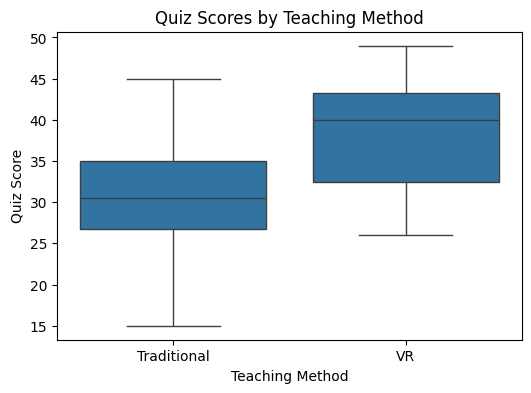

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Method", y="Score", data=data)

plt.title("Quiz Scores by Teaching Method")
plt.xlabel("Teaching Method")
plt.ylabel("Quiz Score")

plt.show()

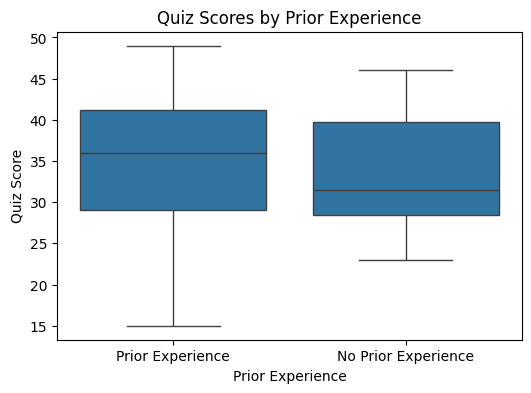

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Experience", y="Score", data=data)

plt.title("Quiz Scores by Prior Experience")
plt.xlabel("Prior Experience")
plt.ylabel("Quiz Score")

plt.show()

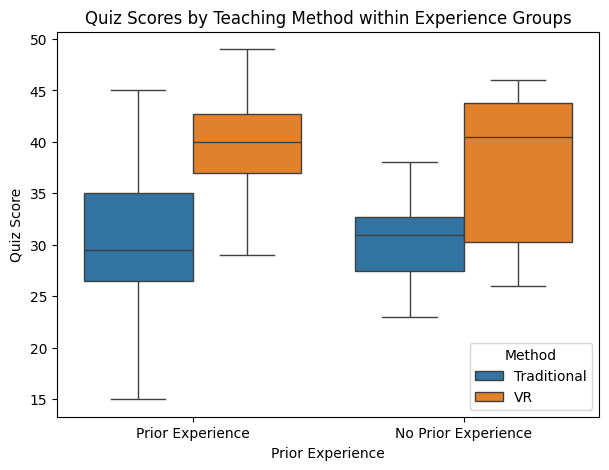

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Experience", y="Score", hue="Method", data=data)

plt.title("Quiz Scores by Teaching Method within Experience Groups")
plt.xlabel("Prior Experience")
plt.ylabel("Quiz Score")

plt.show()

Exploratory analysis was performed using summary statistics and boxplots to compare quiz scores across teaching methods and experience groups.

From the summary statistics, the average quiz score for the **VR** group was **38.5**, while the **Traditional** group had an average score of **30.8**. This shows that students in the VR session scored higher on average than students in the traditional session.

When looking at prior experience alone, students with **Prior Experience** had a mean score of **35.3**, while students with **No Prior Experience** had a mean score of **34.0**. This difference is small, which suggests that prior experience by itself may not have a strong overall effect on quiz scores.

The grouped summary statistics give a clearer picture. Among students with **Prior Experience**, the VR group had a mean score of **39.7**, compared to **30.9** for the Traditional group. Among students with **No Prior Experience**, the VR group had a mean score of **37.3**, while the Traditional group had a mean score of **30.7**. In both experience groups, the VR method had noticeably higher average scores than the Traditional method.

The boxplots support the same conclusion. The VR scores are centered higher than the Traditional scores in both experience groups. There are some differences in spread across the groups. In the **Prior Experience** group, the Traditional box is somewhat wider, showing more variability than the VR group. In the **No Prior Experience** group, the VR box is wider than the Traditional box, showing greater variability there. Even so, the VR groups still have higher centers in both blocks.

Overall, the summary statistics and visualizations suggest that the teaching method affects quiz scores, with the VR session leading to higher scores than the Traditional session. These exploratory results support the **alternative hypothesis** more strongly than the null hypothesis.

**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using *both* a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# two-way ANOVA with block
model = ols('Score ~ C(Method) + C(Experience)', data=data).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

               sum_sq    df          F    PR(>F)
C(Method)       592.9   1.0  12.441048  0.001140
C(Experience)    16.9   1.0   0.354619  0.555135
Residual       1763.3  37.0        NaN       NaN


In [ ]:
from scipy.stats import shapiro

residuals = model.resid

shapiro_test = shapiro(residuals)

print("Shapiro-Wilk Test Statistic:", shapiro_test.statistic)
print("p-value:", shapiro_test.pvalue)

Shapiro-Wilk Test Statistic: 0.9869121871043949
p-value: 0.9172749088112122


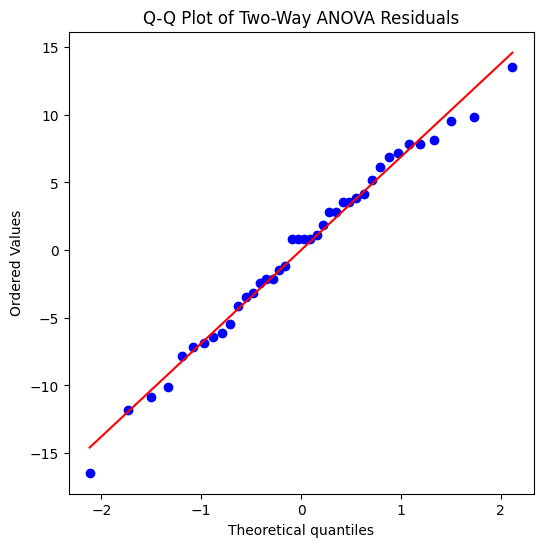

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Q-Q Plot of Two-Way ANOVA Residuals")

plt.show()

A two-way ANOVA model was built to evaluate the effect of teaching method (VR vs Traditional) while accounting for prior experience with elderly patients as a blocking factor.

To assess the normality assumption, both a statistical test and a visual method were used. First, the Shapiro–Wilk test was applied to the residuals from the two-way ANOVA model. The test produced a p-value of **0.917**. Since this value is much greater than 0.05, we fail to reject the null hypothesis of the Shapiro–Wilk test. This suggests that the residuals do not significantly deviate from a normal distribution.

A Q–Q plot of the residuals was also examined. Most of the points lie very close to the reference line, indicating that the residuals follow an approximately normal pattern. Although there are very small deviations at the extreme ends of the plot, these are minor and not unusual with a sample of this size.

Based on both the Shapiro–Wilk test and the Q–Q plot, the normality assumption for the two-way ANOVA model appears to be reasonably satisfied.

**Question 8.** Test the assumption of homogeneity of variance using *both* a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

In [ ]:
from scipy.stats import levene

g1 = data[(data["Method"]=="Traditional") & (data["Experience"]=="Prior Experience")]["Score"]
g2 = data[(data["Method"]=="Traditional") & (data["Experience"]=="No Prior Experience")]["Score"]
g3 = data[(data["Method"]=="VR") & (data["Experience"]=="Prior Experience")]["Score"]
g4 = data[(data["Method"]=="VR") & (data["Experience"]=="No Prior Experience")]["Score"]

levene_test = levene(g1, g2, g3, g4)

print("Levene Test Statistic:", levene_test.statistic)
print("p-value:", levene_test.pvalue)

Levene Test Statistic: 1.1638738994603803
p-value: 0.33694602944077134


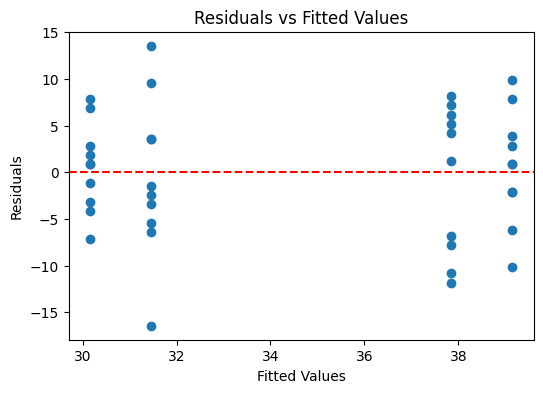

In [ ]:
import matplotlib.pyplot as plt

fitted_vals = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(6,4))
plt.scatter(fitted_vals, residuals)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

The homogeneity of variance assumption was checked using both a statistical test and a visual method.

First, Levene’s test was used to compare the variances across the four groups formed by teaching method and prior experience. The test produced a p-value of **0.337**. Since this value is greater than 0.05, we fail to reject the null hypothesis of equal variances. This suggests that the group variances are not significantly different.

A residuals versus fitted values plot was also examined as a visual check. The points appear randomly scattered around zero, with no clear pattern or funnel shape. The spread of the residuals looks reasonably similar across the fitted values.

Based on both the Levene test and the residual plot, the homogeneity of variance assumption for the two-way ANOVA model appears to be satisfied.

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

The two-way ANOVA results for the treatment factor (teaching method) produced an F-statistic of **12.44** with an associated p-value of **0.00114**.

Since the p-value is less than the significance level of 0.05, we reject the null hypothesis that the mean quiz scores are the same for the VR and traditional teaching methods.

This provides strong evidence that the teaching method has an effect on quiz scores. Therefore, the results more strongly support the **alternative hypothesis**, which states that the mean quiz scores differ between the teaching methods.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=data["Score"],
                          groups=data["Method"],
                          alpha=0.05)

print(tukey)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
   group1   group2 meandiff p-adj lower   upper  reject
-------------------------------------------------------
Traditional     VR      7.7 0.001 3.3184 12.0816   True
-------------------------------------------------------


In [ ]:
from scipy.stats import ttest_ind

vr = data[data["Method"]=="VR"]["Score"]
trad = data[data["Method"]=="Traditional"]["Score"]

ttest = ttest_ind(vr, trad)

print("t-statistic:", ttest.statistic)
print("p-value:", ttest.pvalue)

t-statistic: 3.557526346855645
p-value: 0.001023494726142043


Since the ANOVA results supported the alternative hypothesis, a Tukey HSD post-hoc test was performed to compare the levels of the treatment factor, as instructed.

The Tukey test compared the two teaching methods (Traditional and VR). The results showed a mean difference of **7.7 points**, with a p-value of **0.001**. Since the p-value is less than 0.05, the difference between the VR and Traditional teaching methods is statistically significant. This indicates that students who participated in the VR session scored significantly higher on the quiz compared to those in the Traditional session.

However, because the treatment factor only has **two levels (VR and Traditional)**, a Tukey post-hoc test is not strictly necessary. Post-hoc tests like Tukey are mainly used when there are **three or more treatment groups** to determine which pairs differ. With only two groups, the comparison can be made directly using a **two-sample t-test**.

A two-sample t-test was therefore also conducted. The test produced a **t-statistic of 3.56** with a **p-value of 0.0010**, which also indicates a statistically significant difference between the VR and Traditional teaching methods.

Both the Tukey test and the two-sample t-test lead to the same conclusion: the **VR teaching method results in significantly higher quiz scores than the Traditional method**.

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations of this experiment and suggestions for future experimentation.

This study examined whether using a virtual reality (VR) teaching session improves nursing students’ attitudes toward elderly people compared to a traditional teaching method, while accounting for prior experience working with elderly patients. The two-way ANOVA results showed a statistically significant effect of the teaching method on quiz scores (F = 12.44, p = 0.00114). Students who participated in the VR session had higher average quiz scores than those in the traditional session. Tukey’s HSD test, along with a two-sample t-test, also confirmed that the difference between the VR and traditional teaching methods was statistically significant. In contrast, prior experience with elderly people did not show a significant effect on quiz scores. Overall, these results suggest that the VR learning experience may be more effective than the traditional method in improving students’ attitudes toward elderly patients.

There are several limitations to this experiment. The total sample size was 40 students, which is reasonable for statistical analysis, but each treatment and experience group contained only 10 observations. This relatively small group size may limit how well the results generalize to a larger population of nursing students. In addition, the study measured attitudes using a single quiz immediately after the class session, so the results may not reflect long-term changes in attitudes or learning. Other factors such as students’ familiarity with VR technology, individual interest in elderly care, or differences in engagement during the session may also influence the results.

Future studies could include a larger and more diverse sample of students to improve the reliability of the results. Researchers could also examine long-term outcomes, such as whether VR training leads to lasting improvements in attitudes or performance when working with elderly patients. Additionally, future experiments could compare multiple VR scenarios or combine VR with traditional teaching methods to better understand how immersive technologies can improve healthcare education.

**PART 3 INSTRUCTIONS:** Please briefly respond to the following questions:

**Question 1.** Give a reason why one-factor CRD wouldn't generally be appropriate for studies involving human participants.

A one-factor completely randomized design (CRD) is often not ideal for studies involving human participants because people naturally differ in many ways, such as prior experience, background knowledge, motivation, or personal preferences. These differences can affect the outcome of the study. If these factors are not controlled or accounted for, they may introduce additional variability that makes it harder to detect the true effect of the treatment.

**Question 2.** What is the purpose of post-hoc tests?

The purpose of post-hoc tests is to determine which specific group means are different after an overall statistical test, such as ANOVA, shows that a significant difference exists among the groups. Since ANOVA only tells us that at least one group mean differs, post-hoc tests are used to make pairwise comparisons between groups while controlling for the increased risk of Type I error.

**Question 3.** Explain the difference between RBD and LSD.

A Randomized Block Design (RBD) is used when researchers want to control for the effect of a known source of variability by grouping similar experimental units into blocks before randomly assigning treatments within each block. This helps reduce variation caused by that factor and improves the accuracy of the treatment comparison.

A Latin Square Design (LSD), on the other hand, is used when there are two blocking factors that may influence the outcome. In an LSD, treatments are arranged so that each treatment appears exactly once in each row and each column, allowing the experiment to control for two sources of variability at the same time.

**Question 4.** Explain why randomization is important in designing experiments.

Randomization is important in experimental design because it helps ensure that treatments are assigned to participants in an unbiased way. This reduces the chance that other uncontrolled factors will systematically affect one treatment group more than another. Randomization helps balance unknown or unmeasured variables across groups, which allows researchers to make stronger conclusions about the effect of the treatment.

**Question 5.** Explain why replication is important in designing experiments.

Replication is important because it allows researchers to measure the natural variability in the data and obtain more reliable estimates of treatment effects. By observing the treatment multiple times across different experimental units, replication increases the precision of the results and improves the ability to detect real differences between treatments.